# 14 · Predictores Correlacionados

**Problema:** en regresión múltiple, los predictores suelen estar correlacionados entre sí.  
Esto puede producir **coeficientes con signo contraintuitivo** (por ejemplo, que agregar un dormitorio *reduzca* el precio).

> *"The coefficient for Bedrooms is negative! This implies that adding a bedroom to a house will reduce its value."*  
> — *Practical Statistics for Data Scientists*

En este notebook vamos a:
1. Reproducir el fenómeno con nuestros datos de vivienda
2. Entender **por qué** ocurre
3. Ver cómo cambian los coeficientes al eliminar variables correlacionadas
4. Visualizar la correlación entre predictores

In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

df = pd.read_csv("../data/housing.csv")
print(f"Filas: {len(df)}")
df.head(3)

Filas: 100


,id,square_meters,age,price,bedrooms,bathrooms,floor,distance_to_center_km,has_garage,build_quality,property_type,neighborhood
0,1,152,33,338200,4,2,1,4.3,1,10,Single Family,El Prado
1,2,142,24,266900,4,3,8,6.6,1,3,Single Family,Las Flores
2,3,64,11,170800,2,1,1,14.0,1,6,Apartment,El Mirador


## 1 · Modelo completo: ¿coeficiente negativo para `bedrooms`?

Ajustemos un modelo con **todas** las variables numéricas relevantes y veamos los coeficientes.

In [4]:
full_vars = [
    "square_meters",
    "bedrooms",
    "bathrooms",
    "build_quality",
    "age",
    "distance_to_center_km",
    "has_garage",
]

X_full = df[full_vars]
y = df["price"]

model_full = LinearRegression().fit(X_full, y)

print("=== Modelo COMPLETO ===")
print(f"Intercepto: {model_full.intercept_:,.0f}")
print(f"R²:         {model_full.score(X_full, y):.3f}\n")
print("Coeficientes:")
for name, coef in zip(full_vars, model_full.coef_):
    sign = "👈 ¡NEGATIVO!" if coef < 0 and name == "bedrooms" else ""
    print(f"  {name:>25s}: {coef:>10,.1f}  {sign}")

=== Modelo COMPLETO ===
Intercepto: 60,239
R²:         0.871

Coeficientes:
              square_meters:      978.4  
                   bedrooms:   -4,494.6  👈 ¡NEGATIVO!
                  bathrooms:    8,200.6  
              build_quality:   13,552.7  
                        age:     -577.9  
      distance_to_center_km:   -1,675.5  
                 has_garage:   23,169.5  


### ¿Cómo es posible que `bedrooms` tenga coeficiente negativo?

**Intuición:** las casas más grandes tienen más dormitorios **y** más metros cuadrados.  
Cuando el modelo ya tiene `square_meters`, `bedrooms` aporta información *residual*:

> *"Dos casas del mismo tamaño: la que tiene más dormitorios tiene habitaciones más pequeñas → se percibe como menos deseable."*

Es decir, `bedrooms` **no causa** que baje el precio — es la **correlación con `square_meters`** la que invierte el signo.

## 2 · Veamos la correlación entre predictores

La raíz del problema: `bedrooms`, `square_meters` y `bathrooms` están **altamente correlacionados**.

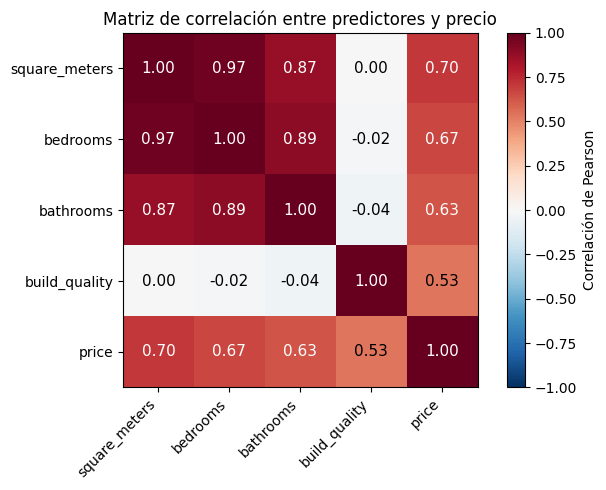

In [5]:
corr_vars = ["square_meters", "bedrooms", "bathrooms", "build_quality", "price"]
corr_matrix = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)

# Etiquetas
ax.set_xticks(range(len(corr_vars)))
ax.set_yticks(range(len(corr_vars)))
ax.set_xticklabels(corr_vars, rotation=45, ha="right")
ax.set_yticklabels(corr_vars)

# Valores dentro de las celdas
for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        val = corr_matrix.iloc[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=11)

plt.colorbar(im, ax=ax, label="Correlación de Pearson")
ax.set_title("Matriz de correlación entre predictores y precio")
plt.tight_layout()
plt.show()

In [6]:
# Correlación específica entre las variables "problemáticas"
print("Correlaciones clave:")
print(f"  bedrooms ↔ square_meters:  {df['bedrooms'].corr(df['square_meters']):.3f}")
print(f"  bedrooms ↔ bathrooms:      {df['bedrooms'].corr(df['bathrooms']):.3f}")
print(f"  square_meters ↔ bathrooms: {df['square_meters'].corr(df['bathrooms']):.3f}")

Correlaciones clave:
  bedrooms ↔ square_meters:  0.974
  bedrooms ↔ bathrooms:      0.894
  square_meters ↔ bathrooms: 0.871


## 3 · Modelo reducido: sin `square_meters`, `bathrooms`

El libro propone eliminar las variables correlacionadas y ver cómo cambia el signo de `bedrooms`.

> Si quitamos `square_meters` y `bathrooms`, el modelo ya no tiene una variable "mejor" para capturar el tamaño → `bedrooms` pasa a ser el proxy del tamaño → **su coeficiente se vuelve positivo**.

In [7]:
reduced_vars = [
    "bedrooms",
    "build_quality",
    "age",
    "distance_to_center_km",
    "has_garage",
]

X_reduced = df[reduced_vars]
model_reduced = LinearRegression().fit(X_reduced, y)

print("=== Modelo REDUCIDO (sin square_meters ni bathrooms) ===")
print(f"Intercepto: {model_reduced.intercept_:,.0f}")
print(f"R²:         {model_reduced.score(X_reduced, y):.3f}\n")
print("Coeficientes:")
for name, coef in zip(reduced_vars, model_reduced.coef_):
    sign = "👈 ¡AHORA POSITIVO!" if coef > 0 and name == "bedrooms" else ""
    print(f"  {name:>25s}: {coef:>10,.1f}  {sign}")

=== Modelo REDUCIDO (sin square_meters ni bathrooms) ===
Intercepto: 60,906
R²:         0.844

Coeficientes:
                   bedrooms:   34,870.2  👈 ¡AHORA POSITIVO!
              build_quality:   13,829.3  
                        age:     -642.8  
      distance_to_center_km:   -1,749.6  
                 has_garage:   23,246.0  


## 4 · Comparación visual de coeficientes

Veamos lado a lado cómo cambia el coeficiente de `bedrooms` entre ambos modelos.

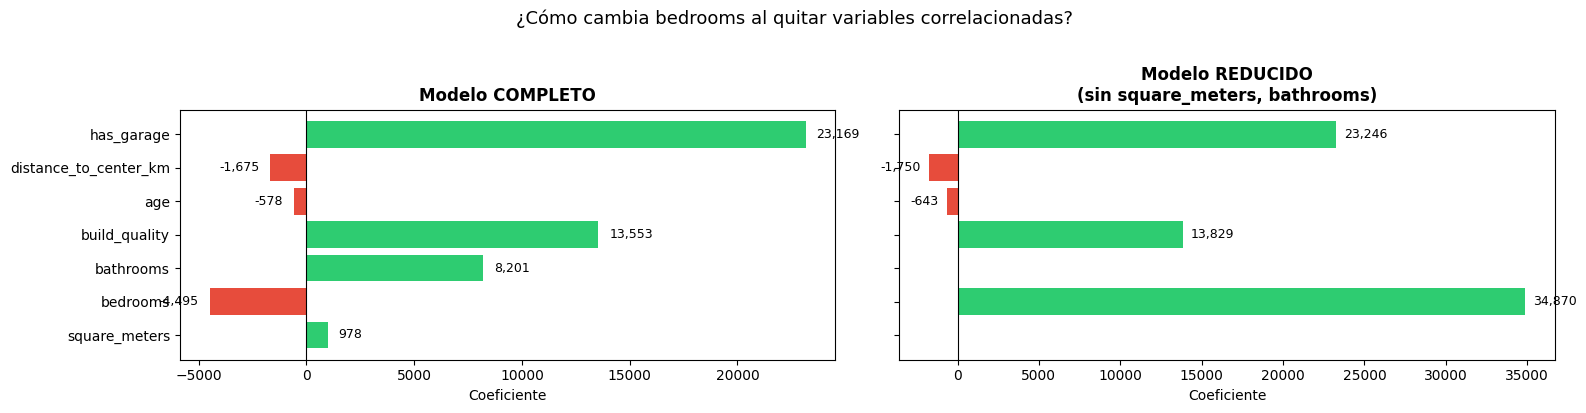

In [ ]:
# Coeficientes de ambos modelos para las variables en común
common_vars = reduced_vars  # todas las del modelo reducido están en el completo
coef_full = {name: coef for name, coef in zip(full_vars, model_full.coef_)}
coef_reduced = {name: coef for name, coef in zip(reduced_vars, model_reduced.coef_)}

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

for ax, (title, coefs) in zip(
    axes,
    [
        ("Modelo COMPLETO", coef_full),
        ("Modelo REDUCIDO\n(sin square_meters, bathrooms)", coef_reduced),
    ],
):
    names = list(coefs.keys())
    vals = list(coefs.values())
    colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in vals]
    bars = ax.barh(names, vals, color=colors)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Coeficiente")
    for bar, val in zip(bars, vals):
        ax.text(
            val + (500 if val >= 0 else -500),
            bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f}",
            va="center",
            ha="left" if val >= 0 else "right",
            fontsize=9,
        )

plt.suptitle(
    "¿Cómo cambia bedrooms al quitar variables correlacionadas?", fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

## 5 · Scatter: la correlación que causa el problema

Veamos gráficamente por qué `bedrooms` y `square_meters` son redundantes.

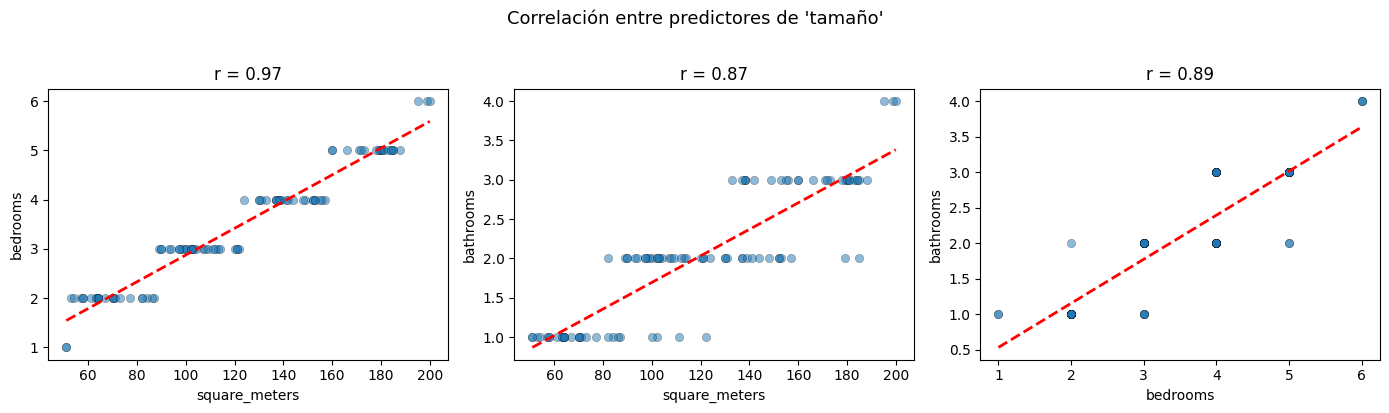

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

pairs = [
    ("square_meters", "bedrooms"),
    ("square_meters", "bathrooms"),
    ("bedrooms", "bathrooms"),
]

for ax, (x, y_var) in zip(axes, pairs):
    ax.scatter(df[x], df[y_var], alpha=0.5, edgecolors="k", linewidth=0.3)
    r = df[x].corr(df[y_var])
    ax.set_xlabel(x)
    ax.set_ylabel(y_var)
    ax.set_title(f"r = {r:.2f}", fontsize=12)
    # Línea de tendencia
    z = np.polyfit(df[x], df[y_var], 1)
    x_line = np.linspace(df[x].min(), df[x].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), "r--", linewidth=2)

plt.suptitle("Correlación entre predictores de 'tamaño'", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6 · ¿Importa para la predicción?

Los predictores correlacionados **no dañan la capacidad predictiva** del modelo — solo dificultan la **interpretación** de los coeficientes individuales.

Comparemos el R² con validación cruzada:

In [10]:
from sklearn.model_selection import cross_val_score

cv_full = cross_val_score(LinearRegression(), X_full, y, cv=5, scoring="r2")
cv_reduced = cross_val_score(LinearRegression(), X_reduced, y, cv=5, scoring="r2")

print(f"{'Modelo':<35} {'R² CV (media ± std)'}")
print(f"{'-' * 55}")
print(f"{'Completo (7 variables)':<35} {cv_full.mean():.3f} ± {cv_full.std():.3f}")
print(
    f"{'Reducido (5 variables)':<35} {cv_reduced.mean():.3f} ± {cv_reduced.std():.3f}"
)
print(
    f"\nEl modelo completo predice {'mejor' if cv_full.mean() > cv_reduced.mean() else 'peor'},"
)
print(f"aunque los coeficientes individuales sean más difíciles de interpretar.")

Modelo                              R² CV (media ± std)
-------------------------------------------------------
Completo (7 variables)              0.804 ± 0.053
Reducido (5 variables)              0.762 ± 0.080

El modelo completo predice mejor,
aunque los coeficientes individuales sean más difíciles de interpretar.


## 7 · Multicolinealidad: VIF (Variance Inflation Factor)

Una forma cuantitativa de detectar predictores correlacionados es el **VIF**:

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

Donde $R^2_j$ es el R² de regresar la variable $j$ contra **todas las demás** predictoras.

| VIF | Interpretación |
|-----|----------------|
| 1 | Sin correlación |
| 1–5 | Correlación moderada |
| 5–10 | Alta correlación ⚠️ |
| >10 | Multicolinealidad severa 🚨 |

In [11]:
# Calculamos VIF manualmente (sin dependencias extra)
def calc_vif(X, var_names):
    """Calcula VIF para cada variable en X."""
    vifs = []
    for i, name in enumerate(var_names):
        y_i = X[:, i]
        X_rest = np.delete(X, i, axis=1)
        r2 = LinearRegression().fit(X_rest, y_i).score(X_rest, y_i)
        vif = 1 / (1 - r2) if r2 < 1 else float("inf")
        vifs.append((name, vif, r2))
    return vifs


print(f"{'Variable':<25} {'VIF':>8}  {'R² vs resto':>12}  {'Nivel'}")
print(f"{'-' * 65}")
for name, vif, r2 in calc_vif(X_full.values, full_vars):
    level = (
        "🚨 Severa"
        if vif > 10
        else "⚠️  Alta"
        if vif > 5
        else "✅ OK"
        if vif < 5
        else ""
    )
    print(f"  {name:<23} {vif:>8.1f}  {r2:>11.3f}   {level}")

Variable                       VIF   R² vs resto  Nivel
-----------------------------------------------------------------
  square_meters               19.5        0.949   🚨 Severa
  bedrooms                    23.6        0.958   🚨 Severa
  bathrooms                    5.2        0.808   ⚠️  Alta
  build_quality                1.1        0.050   ✅ OK
  age                          1.0        0.025   ✅ OK
  distance_to_center_km        1.1        0.054   ✅ OK
  has_garage                   1.0        0.047   ✅ OK


## 8 · Resumen

| Concepto | Detalle |
|----------|---------|
| **Problema** | Predictores correlacionados → coeficientes con signo contraintuitivo |
| **Causa** | Variables como `bedrooms`, `square_meters`, `bathrooms` miden lo mismo: *tamaño* |
| **Efecto en predicción** | Mínimo — el modelo predice bien de todas formas |
| **Efecto en interpretación** | Grave — no puedes confiar en el signo ni magnitud de coeficientes individuales |
| **Detección** | Matriz de correlación, VIF |
| **Solución** | Eliminar variables redundantes **o** usar técnicas de regularización (Ridge, Lasso) |

### Regla práctica

```
¿Quieres PREDECIR?  → la multicolinealidad no es un problema grave
¿Quieres EXPLICAR?  → debes tratarla (eliminar variables o regularizar)
```